In [44]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(os.path.abspath('')))))
from src.modules.GMMLabelCorrector import GMMLabelCorrector
from src.utils.data_utils import load_full_data
from transformers import BertTokenizer, BertModel
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import umap
import seaborn as sns
from matplotlib.patches import Ellipse
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

In [35]:
df = pd.read_csv('train/expanded_full_v2.csv')
df.fillna('', inplace=True)
embeddings = np.load('train/bert_embeddings_expanded_full_v2.npy')
text = (df['title'] + ' ' + df['selftext'])
original_labels = df['label'].values

In [83]:
gmm = GMMLabelCorrector(embeddings, 'umap', n_components=2)

/opt/anaconda3/envs/diss/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/diss/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embeddings shape: (126488, 2)


In [84]:
threshold_min = 0.6
threshold_max = 0.95
threshold_dict = {}
for threshold in np.arange(threshold_min, threshold_max, 0.05):
    t = round(threshold, 2)
    print(f"Threshold: {t}")
    probs = gmm.gmm.predict_proba(gmm.reduced_embeddings)
    corrected_labels = gmm.threshold_predict(gmm.reduced_embeddings, df['label'].values, threshold=threshold)
    print("Flips 0 -> 1:", sum((original == 0) and (corrected == 1) for original, corrected in zip(original_labels, corrected_labels)))
    print("Flips 1 -> 0:", sum((original == 1) and (corrected == 0) for original, corrected in zip(original_labels, corrected_labels)))
    zero2one = []
    one2zero = []
    for sample, prob, original, corrected in zip(text.values, probs, original_labels, corrected_labels):
        if int(original) == 0 and int(corrected) == 1:
            zero2one.append((sample, prob))
        elif int(original) == 1 and int(corrected) == 0:
            one2zero.append((sample, prob))
    threshold_dict[t] = {
        'zero2one': zero2one,
        'one2zero': one2zero,
        'corrected_labels': corrected_labels
    }
    print("-" * 50)

Threshold: 0.6
Flips 0 -> 1: 40561
Flips 1 -> 0: 26925
--------------------------------------------------
Threshold: 0.65
Flips 0 -> 1: 38710
Flips 1 -> 0: 25196
--------------------------------------------------
Threshold: 0.7
Flips 0 -> 1: 36651
Flips 1 -> 0: 23457
--------------------------------------------------
Threshold: 0.75
Flips 0 -> 1: 34188
Flips 1 -> 0: 21700
--------------------------------------------------
Threshold: 0.8
Flips 0 -> 1: 31172
Flips 1 -> 0: 19843
--------------------------------------------------
Threshold: 0.85
Flips 0 -> 1: 27306
Flips 1 -> 0: 17842
--------------------------------------------------
Threshold: 0.9
Flips 0 -> 1: 22745
Flips 1 -> 0: 15342
--------------------------------------------------


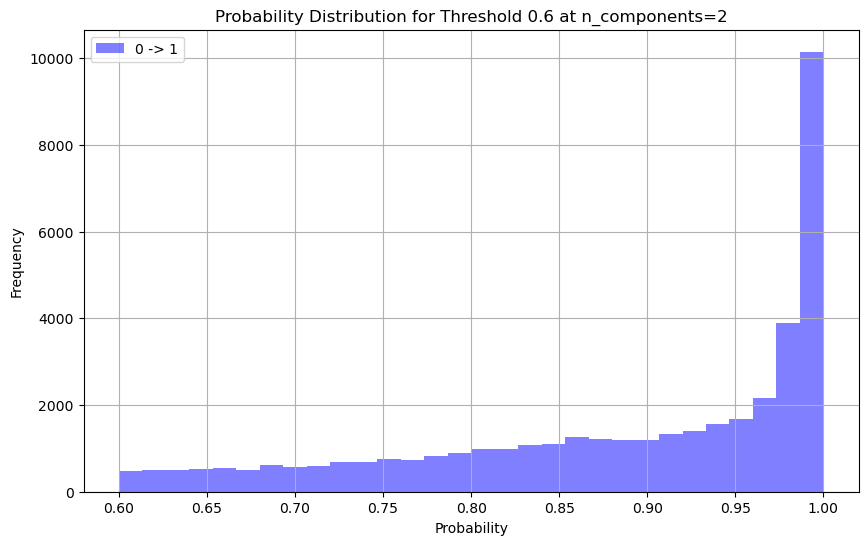

In [86]:
# Plot a histogram of probabilities for threshold=0.6 using threshold_dict for zero2one and one2zero with different bars
threshold = 0.6
zero2one_probs = [prob[1][1] for prob in threshold_dict[threshold]['zero2one']]
plt.figure(figsize=(10, 6))
plt.hist(zero2one_probs, bins=30, alpha=0.5, label='0 -> 1', color='blue')
plt.title(f'Probability Distribution for Threshold {threshold} at n_components=2')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.legend()
plt.grid()

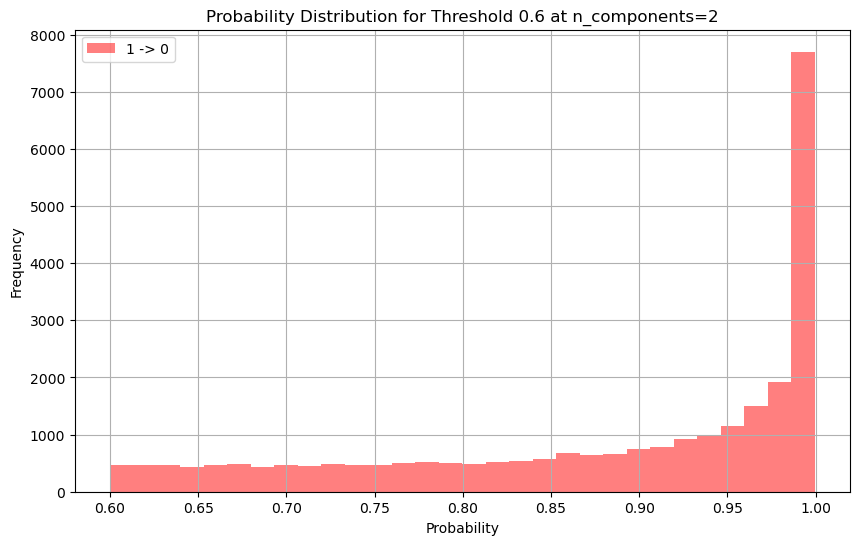

In [87]:
# Plot a histogram of probabilities for threshold=0.6 using threshold_dict for zero2one and one2zero with different bars
threshold = 0.6
zero2one_probs = [prob[1][0] for prob in threshold_dict[threshold]['one2zero']]
plt.figure(figsize=(10, 6))
plt.hist(zero2one_probs, bins=30, alpha=0.5, label='1 -> 0', color='red')
plt.title(f'Probability Distribution for Threshold {threshold} at n_components=2')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.legend()
plt.grid()

In [74]:
zero2one_9 = threshold_dict[0.60]['zero2one']
one2zero_9 = threshold_dict[0.60]['one2zero']

In [75]:
for sample in zero2one_9:
    print(f"0 -> 1: {sample[0]} (Prob: {max(sample[1]):.2f})")

0 -> 1: Question for British Women  (Prob: 0.99)
0 -> 1: Distorted my sleeping pattern  (Prob: 0.77)
0 -> 1: Nice  (Prob: 1.00)
0 -> 1: Pointless  (Prob: 1.00)
0 -> 1: Inflation  (Prob: 0.91)
0 -> 1: Casual serious crime  (Prob: 1.00)
0 -> 1: ‘Covid ’ Winter Cold / Flu illness  (Prob: 1.00)
0 -> 1: Not letting either of them win  (Prob: 1.00)
0 -> 1: NHS Issues  (Prob: 1.00)
0 -> 1: Forgetting Brands  (Prob: 1.00)
0 -> 1: Too true…  (Prob: 1.00)
0 -> 1: Throb  (Prob: 1.00)
0 -> 1: Commentating the greatest leg in darts history  (Prob: 0.98)
0 -> 1: Looking for a few days away in the UK  (Prob: 0.86)
0 -> 1: trade  (Prob: 0.99)
0 -> 1: Truth  (Prob: 1.00)
0 -> 1: Shoplifting baby food.  (Prob: 1.00)
0 -> 1: Gambling  (Prob: 1.00)
0 -> 1: Heartbroken  (Prob: 1.00)
0 -> 1: Post theft  (Prob: 0.96)
0 -> 1: Undergraduate Dissertation Survey  (Prob: 0.97)
0 -> 1: Survey on sustainable and ethical clothing  (Prob: 0.98)
0 -> 1: Sounds wonderful  (Prob: 1.00)
0 -> 1: Just popping in to grab so

In [76]:
for sample in one2zero_9:
    print(f"1 -> 0: {sample[0]} (Prob: {max(sample[1]):.2f})")

1 -> 0: Bipolar  voices Sozz this is a weird question but my hearing voices thing is getting worse like I was accidentally speaking to them. They aren't bad voices they are random people chatting been happing since ish. Is that normal to just have normal people talk outside ur ear and I thought the tv was on there and it wasn't. (Prob: 0.95)
1 -> 0: I have race car thoughts and the voices are back and i can't sleep maybe it's mania i dunno but i'm having a gazillion thoughts like race car and i should be tired but im not tired and im fine im great but it's late. 
and there's someone's watching me, i googled for necklaces then i went on instagram and got an ad for necklaces, i have a new phone that's second hand so i think it's the old owner stalking me

i really don't know what's going on and the voices keep talking to me how do i make them stop (Prob: 1.00)
1 -> 0: sleeping while somewhat hypomanic? I haven't slept in like  hours, I'm not tired at all and I have work tomorrow in less 

In [88]:
# Notes
# As n_components increases, the number of corrections decreases
# There are fewer 0 -> 1 corrections than 1 -> 0 corrections which is the opposite of our assumption
# Most probabilities for both ways are near 1.00, which indicates overconfidence in the model
    # Analysing some corrections with very high probabilities, they are mostly false positives
    # The best 'smooth' distribution is with n_components=2
# The silhouette score is very low for all n_components (0.10 - 0.20)
# Tried n_components=2, 5, 10, 20, 50